## How do I understand that Docling has parsed the text from our Architecture diagram?

Exactly — this is the right question for Stage 1.4.2.5.4.
There is an important distinction:

Docling detecting our architecture diagram is NOT the same as Docling parsing the text inside the diagram.
Our architecture diagram is an embedded image. The words:

      Producer
      Event Hubs
      Stream Consumer
      Data Explorer

are pixels inside that image.

So we need to prove whether Docling has actually extracted those words.

## Step 1 — Know what we are testing

Our PDF contains:

      PDF
      │
      ├── Normal PDF text
      │
      ├── Table
      │
      └── Architecture diagram
            │
            ├── Producer
            ├── Event Hubs
            ├── Stream Consumer
            └── Data Explorer
The architecture diagram is an image:

      PictureItem
      │
      └── image pixels
            │
            ├── "Producer"
            ├── "Event Hubs"
            └── ...
Simply having:

In [ ]:
len(doc.pictures)

return 1 proves only:

Docling detected a picture.
It does not prove that Docling read the text inside it.
## Step 2 — The simplest test

Run this after converting the PDF:

In [3]:
from pathlib import Path

pdf_path = Path(
    "D:\\AI Learning\\rag-learning\\data\\raw\\pdf\\Stage 1.4.2.5.4-docling_table_image_formula_sample.pdf"
)

print(pdf_path)
print(pdf_path.exists())

D:\AI Learning\rag-learning\data\raw\pdf\Stage 1.4.2.5.4-docling_table_image_formula_sample.pdf
True


In [15]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

In [16]:
# 1. Enable picture image extraction in pipeline options
pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True  # Required to populate picture images

# 2. Attach options to the converter
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

In [17]:
result = converter.convert(pdf_path)

doc = result.document

[INFO] 2026-08-21 14:48:30,454 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-08-21 14:48:30,458 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-08-21 14:48:30,499 [RapidOCR] download_file.py:60: File exists and is valid: D:\AI Learning\rag-learning\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-08-21 14:48:30,500 [RapidOCR] main.py:50: Using D:\AI Learning\rag-learning\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-08-21 14:48:30,892 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-08-21 14:48:30,894 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-08-21 14:48:30,899 [RapidOCR] download_file.py:60: File exists and is valid: D:\AI Learning\rag-learning\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-08-21 14:48:30,900 [RapidOCR] main.py:50: Using D:\AI Learning\rag-learning\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobil

In [18]:
markdown_text = doc.export_to_markdown()

print(markdown_text)

## Stage 1.4.2.5.4 - Docling Table / Image / Formula Understanding

This document is intentionally designed as a controlled test document for Docling. It contains ordinary text, a structured table, an embedded architecture image, and a mathematical formula.

## 1. Structured Table

|   Stage | Component           | Purpose                              |
|---------|---------------------|--------------------------------------|
|       1 | Event Producer      | Publishes business events            |
|       2 | Azure Event Hubs    | Ingests and partitions event streams |
|       3 | Stream Consumer     | Reads and transforms events          |
|       4 | Azure Data Explorer | Stores data for analytics            |

## 2. Architecture Image / Figure

## Event Processing Architecture

Figure 1 - Event processing architecture

<!-- image -->

## 3. Mathematical Formula

The following mathematical expression is included as an image so that we can separately observe how Docling treats formula-

Now specifically search for the words that exist only inside our architecture image:

In [19]:
# this is the key code to understand whether Docling can detect the architecture diagram text or not. 
# The following words are the key words in the architecture diagram. 
# If Docling can detect these words, it means that Docling can detect the architecture diagram text.

architecture_words = [
    "Producer",
    "Event Hubs",
    "Stream Consumer",
    "Data Explorer",
]

for word in architecture_words:
    print(f"{word:20} -> {word in markdown_text}")

Producer             -> True
Event Hubs           -> True
Stream Consumer      -> True
Data Explorer        -> True


If you get:

    Producer             -> False
    Event Hubs           -> False
    Stream Consumer      -> False
    Data Explorer        -> False

then the Markdown export has not extracted those words from the architecture image.

That's what I expect with our current baseline configuration.

## Step 3 — Don't stop at Markdown
Because we learned in Stage 1.4.2.5.3 that:

    export_to_markdown() is an output representation, not the complete Docling document model.
    
So let's search the actual DoclingDocument.
Run:

In [21]:
search_words = [
    "Producer",
    "Event Hubs",
    "Stream Consumer",
    "Data Explorer",
]

for item, level in doc.iterate_items():

    text = getattr(item, "text", "")

    if text:
        for word in search_words:
            if word.lower() in text.lower():
                print(
                    f"FOUND: {word!r} "
                    f"in {type(item).__name__}"
                )

If nothing is printed
That means:

    DoclingDocument
        │
        ├── PictureItem        ✅
        │
        └── TextItem containing
            "Producer"         ❌
            "Event Hubs"       ❌
            "Stream Consumer"  ❌
            "Data Explorer"    ❌
Therefore:

    Docling detected the architecture image, but it did not parse the text inside the image.

## Step 4 — This is the key experiment

Let's explicitly inspect our picture.

Number of pictures: 1
<class 'docling_core.types.doc.items.picture.picture.PictureItem'>
self_ref='#/pictures/0' parent=RefItem(cref='#/body') children=[RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9')] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.PICTURE: 'picture'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=89.04425054473585, t=421.15332353903943, r=452.5822882712545, b=302.1633793329843, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))] source=[] comments=[] captions=[RefItem(cref='#/texts/5')] references=[] footnotes=[] image=ImageRef(mimetype='image/png', dpi=72, size=Size(width=364.0, height=119.0), uri=AnyUrl('')) annotations=[]

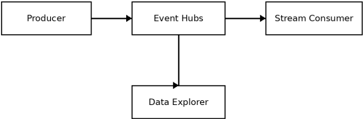

In [22]:
print("Number of pictures:", len(doc.pictures))

picture = doc.pictures[0]

print(type(picture))
print(picture)

You should see something representing a:

    PictureItem
    
Now:

In [23]:
picture_image = picture.get_image(doc)

print(type(picture_image))

<class 'PIL.PngImagePlugin.PngImageFile'>


After enabling:

In [24]:
pipeline_options.generate_picture_images = True

we should get:

<class 'PIL.Image.Image'>

Now we have:

      Docling
         │
         └── PictureItem
               │
               └── PIL Image

But still no guarantee that the text inside the image has been recognized.

## Step 5 — The easiest visual proof

Save the extracted image:

In [25]:
picture_image.save("architecture_from_docling.png")

Open it.

You'll see something like:

    ┌────────────────────────────────────────┐
    │                                        │
    │  Producer → Event Hubs → Stream        │
    │                         Consumer       │
    │                         ↓              │
    │                    Data Explorer       │
    │                                        │
    └────────────────────────────────────────┘

That's the image itself.

The text is still just pixels.

Think of it like this:

    Image
    │
    ├── pixel: P
    ├── pixel: r
    ├── pixel: o
    ├── pixel: d
    └── ...

A vision/OCR system has to convert those pixels into:

    "Producer"

## Step 6 — So how do we make Docling understand the text?

This is where our OCR / enrichment configuration becomes important.
There are actually two different problems:

Problem A — Detect the picture

    PDF
    ↓
    Picture detected
    ↓
    PictureItem

We have already demonstrated this.

Problem B — Understand the picture

    Picture
    ↓
    OCR / vision processing
    ↓
    "Producer"
    "Event Hubs"
    "Stream Consumer"
    "Data Explorer"

That's a different capability.

## Step 7 — An important experiment for your learning

Let's first establish the baseline.

Run this cell:

In [26]:
markdown_text = doc.export_to_markdown()

words = [
    "Producer",
    "Event Hubs",
    "Stream Consumer",
    "Data Explorer",
]

print("========== ARCHITECTURE TEXT TEST ==========")

for word in words:
    print(
        f"{word:20} : "
        f"{'FOUND' if word.lower() in markdown_text.lower() else 'NOT FOUND'}"
    )

========== ARCHITECTURE TEXT TEST ==========
Producer             : FOUND
Event Hubs           : FOUND
Stream Consumer      : FOUND
Data Explorer        : FOUND


Then run:

In [27]:
print("\n========== DOCLING DOCUMENT TEST ==========")

for item, level in doc.iterate_items():

    text = getattr(item, "text", "")

    if text:
        print(
            type(item).__name__,
            "=>",
            repr(text[:200])
        )


========== DOCLING DOCUMENT TEST ==========
SectionHeaderItem => 'Stage 1.4.2.5.4 - Docling Table / Image / Formula Understanding'
TextItem => 'This document is intentionally designed as a controlled test document for Docling. It contains ordinary text, a structured table, an embedded architecture image, and a mathematical formula.'
SectionHeaderItem => '1. Structured Table'
SectionHeaderItem => '2. Architecture Image / Figure'
SectionHeaderItem => 'Event Processing Architecture'
TextItem => 'Figure 1 - Event processing architecture'
SectionHeaderItem => '3. Mathematical Formula'
TextItem => 'The following mathematical expression is included as an image so that we can separately observe how Docling treats formula-like visual content.'
TextItem => 'Figure 2 - Conditional probability formula'
TextItem => "Experiment: We will inspect Docling's detected tables, pictures, and formula/text elements independently instead of relying only on export_to_markdown()."


Now we can answer scientifically:

    Did the words inside the architecture diagram enter the Docling document model?

## Step 8 — What I expect from our current PDF

For our current test PDF, I expect something like:

========== ARCHITECTURE TEXT TEST ==========

    Producer             : NOT FOUND
    Event Hubs            : NOT FOUND
    Stream Consumer       : NOT FOUND
    Data Explorer         : NOT FOUND

while:

In [ ]:
len(doc.pictures)

returns:



That would give us:

        Architecture diagram detected       ✅
        Architecture image extracted        ✅
        Text inside architecture detected   ❌

And that is an excellent Stage 1.4.2.5.4 result.

## Step 9 — Why this matters for your RAG architecture

This distinction becomes extremely important in production RAG.
Imagine an enterprise PDF containing:

        Architecture Diagram

        Azure Event Hubs
        ↓
        Azure Stream Analytics
        ↓
        Azure Data Explorer

A user asks:

        "Which service receives events from Event Hubs?"

If your ingestion pipeline only does:

        PDF
        ↓
        Picture detected
        ↓
        Store image

then your text-based RAG may have no searchable representation of those words.

But if you perform:

        PDF
        ↓
        Picture detection
        ↓
        Image extraction
        ↓
        OCR / Vision understanding
        ↓
        Structured textual representation
        ↓
        Chunking
        ↓
        Embedding
        ↓
        Vector DB

then the diagram can participate in retrieval.

### The key lesson for Stage 1.4.2.5.4

We now have three levels:

        LEVEL 1
        Picture Detection
                ↓
        "There's an image here."
                ↓
        PictureItem

        LEVEL 2
        Picture Extraction
                ↓
        "Give me the actual image."
                ↓
        PIL Image

        LEVEL 3
        Picture Understanding
                ↓
        "What does this image contain?"
                ↓
        Producer
        Event Hubs
        Stream Consumer
        Data Explorer
                ↓
        OCR / Vision / enrichment

We have already demonstrated Level 1 and are now demonstrating Level 2.

        We have not yet demonstrated Level 3.

And that's exactly where we should go next in Stage 1.4.2.5.4.

Run the two diagnostic cells above first. If all four architecture words show NOT FOUND, we'll then configure the appropriate Docling OCR/picture-enrichment path and repeat the experiment. That will let you see, hands-on, the difference between "Docling detected my diagram" and "Docling understood the text inside my diagram."